# A Quick Introduction to Level 2 Inversions

```{warning}
The level 2 functionality is still in *beta* expect it to change before the 2.0 release.
```

In [7]:
%matplotlib inline

In [18]:
import numpy as np
import matplotlib.pyplot as plt

import dkist

In [55]:
from astropy.coordinates import SkyCoord, SpectralCoord, StokesCoord
from astropy.time import Time
import astropy.units as u

In [4]:
data_path = "/data/dkist/globus/inv.PUYATW/"

In [5]:
inv = dkist.load_dataset(data_path)

INFO: Failed to validate dkist version used by asdf file <asdf._asdf.AsdfFile object at 0x7f39415f2d50>. [dkist.dataset.loader]


In [6]:
inv

Inversion
~~~~~~~~~
Cube keys: ('optical_depth', 'temperature', 'electron_pressure', 'microturbulence', 'mag_strength', 'velocity', 'mag_inclination', 'mag_azimuth', 'geo_height', 'gas_pressure', 'density')
Number of Cubes: 11
Aligned dimensions: [424 508 81]
Aligned physical types: [('custom:pos.helioprojective.lon', 'custom:pos.helioprojective.lat', 'time'), ('custom:pos.helioprojective.lon', 'phys.polarization.stokes', 'custom:pos.helioprojective.lat'), ('phys.absorption.opticalDepth',)]

Profiles
~~~~~~~~
Cube keys: ('NaID_orig', 'NaID_fit', 'FeI630_orig', 'FeI630_fit', 'CaII854_orig', 'CaII854_fit')
Number of Cubes: 6
Aligned dimensions: [424 508 4]
Aligned physical types: [('custom:pos.helioprojective.lon', 'custom:pos.helioprojective.lat', 'time'), ('custom:pos.helioprojective.lon', 'custom:pos.helioprojective.lat'), ('phys.polarization.stokes',)]

In [27]:
fig = inv.plot(np.s_[:,:,0], figure=plt.figure(figsize=(12,10)), inversions=["temperature"])
plt.colorbar(label=f"Temperature [{inv['temperature'].unit:latex}]")

Now let's see if we can plot a 1D temperature vs optical depth line for a single spatial pixel:

In [66]:
one_pix = inv["temperature"][300, 400, :]
one_pix

This Dataset consists of 1 frames.
Files are stored in /data/dkist/globus/inv.PUYATW

This calibration has Dataset ID (no DatasetID).
The unique identifier for the input observe frames (Product ID) is (no ProductID).

This Dataset has 1 pixel and 1 world dimensions.

The data are represented by a <class 'dask.array.core.Array'> object:
dask.array<getitem, shape=(81,), dtype=float64, chunksize=(81,), chunktype=numpy.ndarray>

Array Dim  Axis Name      Data size  Bounds
        0  optical_depth       None  None

World Dim  Axis Name      Physical Type                 Units
        0  optical depth  phys.absorption.opticalDepth  pixel

Correlation between pixel and world axes:

              | PIXEL DIMENSIONS
WORLD DIMENSI | optical_depth
------------- | -------------
optical depth |       x

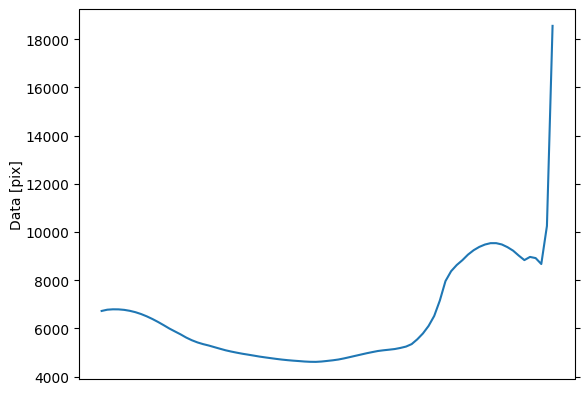

In [67]:
fig = one_pix.plot()

Well that doesn't seem right, it doesn't have an x-axis.

In [68]:
one_pix.axis_world_coords()

(<Quantity [ 1.20000000e+00,  1.10000000e+00,  1.00000000e+00,
             9.00000000e-01,  8.00000000e-01,  7.00000000e-01,
             6.00000000e-01,  5.00000000e-01,  4.00000000e-01,
             3.00000000e-01,  2.00000000e-01,  1.00000000e-01,
            -2.22044605e-16, -1.00000000e-01, -2.00000000e-01,
            -3.00000000e-01, -4.00000000e-01, -5.00000000e-01,
            -6.00000000e-01, -7.00000000e-01, -8.00000000e-01,
            -9.00000000e-01, -1.00000000e+00, -1.10000000e+00,
            -1.20000000e+00, -1.30000000e+00, -1.40000000e+00,
            -1.50000000e+00, -1.60000000e+00, -1.70000000e+00,
            -1.80000000e+00, -1.90000000e+00, -2.00000000e+00,
            -2.10000000e+00, -2.20000000e+00, -2.30000000e+00,
            -2.40000000e+00, -2.50000000e+00, -2.60000000e+00,
            -2.70000000e+00, -2.80000000e+00, -2.90000000e+00,
            -3.00000000e+00, -3.10000000e+00, -3.20000000e+00,
            -3.30000000e+00, -3.40000000e+00, -3.500000

Well that's a list of coords, although why one of them is suddenly -2e-16 I don't know.

## Profiles

In [42]:
inv.profiles

NDCollection
------------
Cube keys: ('NaID_orig', 'NaID_fit', 'FeI630_orig', 'FeI630_fit', 'CaII854_orig', 'CaII854_fit')
Number of Cubes: 6
Aligned dimensions: [424 508 4]
Aligned physical types: [('custom:pos.helioprojective.lon', 'custom:pos.helioprojective.lat', 'time'), ('custom:pos.helioprojective.lon', 'custom:pos.helioprojective.lat'), ('phys.polarization.stokes',)]

In [44]:
inv.profiles["NaID_orig"]

This Dataset consists of 424 frames.
Files are stored in /data/dkist/globus/inv.PUYATW

This calibration has Dataset ID (no DatasetID).
The unique identifier for the input observe frames (Product ID) is (no ProductID).

This Dataset has 4 pixel and 5 world dimensions.

The data are represented by a <class 'dask.array.core.Array'> object:
dask.array<reshape, shape=(424, 508, 767, 4), dtype=float64, chunksize=(1, 508, 767, 4), chunktype=numpy.ndarray>

Array Dim  Axis Name   Data size  Bounds
        0  frame_y          None  None
        1  slit_x           None  None
        2  wavelength       None  None
        3  stokes           None  None

World Dim  Axis Name                Physical Type                   Units
        4  isot(utc; None           time                            s
        3  pos.helioprojective.lat  custom:pos.helioprojective.lat  arcsec
        2  pos.helioprojective.lon  custom:pos.helioprojective.lon  arcsec
        1  wavelength               em.wl            

In [49]:
# yes this is horrible
celestial_frame = inv.profiles["NaID_orig"].wcs.output_frame.frames[2].reference_frame

In [56]:
inv.profiles["NaID_orig"].wcs.world_to_pixel(
    StokesCoord(0),
    SpectralCoord(589.7*u.nm),
    SkyCoord(350*u.arcsec, 540*u.arcsec, frame=celestial_frame),
    Time("2024-04-17T20:25:26.704"),
)

(np.float64(nan),
 np.float64(-4.975177304877434),
 np.float64(285.11061676374123),
 np.float64(0.0))

In [57]:
inv["temperature"]

This Dataset consists of 424 frames.
Files are stored in /data/dkist/globus/inv.PUYATW

This calibration has Dataset ID (no DatasetID).
The unique identifier for the input observe frames (Product ID) is (no ProductID).

This Dataset has 3 pixel and 5 world dimensions.

The data are represented by a <class 'dask.array.core.Array'> object:
dask.array<reshape, shape=(424, 508, 81), dtype=float64, chunksize=(1, 508, 81), chunktype=numpy.ndarray>

Array Dim  Axis Name      Data size  Bounds
        0  frame_y             None  None
        1  slit_x              None  None
        2  optical_depth       None  None

World Dim  Axis Name                Physical Type                   Units
        4  stokes                   phys.polarization.stokes        unknown
        3  isot(utc; None           time                            s
        2  pos.helioprojective.lat  custom:pos.helioprojective.lat  arcsec
        1  pos.helioprojective.lon  custom:pos.helioprojective.lon  arcsec
        0  o

In [61]:
inv["temperature"].wcs.world_to_pixel(
    0*u.pix,  # optical depth
    SkyCoord(350*u.arcsec, 540*u.arcsec, frame=celestial_frame),  # lon/lat
    Time("2024-04-17T20:25:26.704"), # time
    StokesCoord(0),  # Stokes??!
)

NotImplementedError: Support for iterative inverse for transformations with different number of inputs and outputs was not implemented.